# Function 1 Analysis - Week 4

This notebook contains the exploratory analysis for **Function 1** in Week 3. We now have **13 datapoints** to work with after incorporating the last three weeks' queries.

**Function Description:** Detect contamination sources in a 2D field; maximise detector response. This function takes a 2D array as input and returns a 1D array as output. The goal is to maximise the detector response to identify contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading.


## Loading and Displaying the Data

We load the inputs and outputs for function 1 and display them in a table format. Most datapoints remain extremely close to zero – consistent with the idea that only proximity to the source yields a non-zero reading. Datapoint 4 is still the only strongly negative value, so we keep it for completeness despite the distortion it introduces in plots. The Week 1 point in the high-high corner `(0.6, 0.6)` provides a small but positive reading (our current best), while the Week 2 point `(0.62, 0.574)` actually comes back slightly negative, suggesting that moving into the region where `x2 < x1` does not continue the upward trend and should be treated with caution in the optimiser.


In [1]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_1")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1, Week 2, and Week 3 new points
X_new_point_week_1 = np.array([[0.600000, 0.600000]])
y_new_point_week_1 = np.array([0.025559285339829783])
X_new_point_week_2 = np.array([[0.620000, 0.574000]])
y_new_point_week_2 = np.array([-0.00824324367890544])
X_new_point_week_3 = np.array([[0.483000, 0.528000]])
y_new_point_week_3 = np.array([1.0257314214244368e-11])

X = np.vstack([X, X_new_point_week_1, X_new_point_week_2, X_new_point_week_3])
y = np.concatenate([y, y_new_point_week_1, y_new_point_week_2, y_new_point_week_3])

df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


df sorted by y


,x1,x2,y
0,0.600000,0.600000,2.555929e-02
1,0.483000,0.528000,1.025731e-11
2,0.731024,0.733000,7.710875e-16
3,0.683418,0.861057,2.535001e-40
4,0.574329,0.879898,1.033078e-46
5,0.883890,0.582254,6.229856e-48
6,0.319404,0.762959,1.322677e-79
7,0.082507,0.403488,3.606771e-81
8,0.840353,0.264732,3.341771e-124
9,0.312691,0.078723,-2.089093e-91


- **New point (Week 3):** The `(0.483, 0.528)` query returned ≈**1.03e-11**, which is getting us further away from the max!


## Visualisation: x1 vs x2 (excluding datapoint 4)

Since we are in a problem of contamination detection "where only proximity yields a non-zero reading", we can speculate that the x values refer to some kind of 2d mapping. We create a scatter plot of x1 vs x2, coloured by the output value y, excluding datapoint 4 to better visualise the relationships among the other datapoints. We use symlog bins to get useful colour gradients. We can see that all there is a greenish corner in the top right, which also includes our only meaningfully different positive value. It could indeicate that the these points pick up a minimal amount of the contamination source already. 


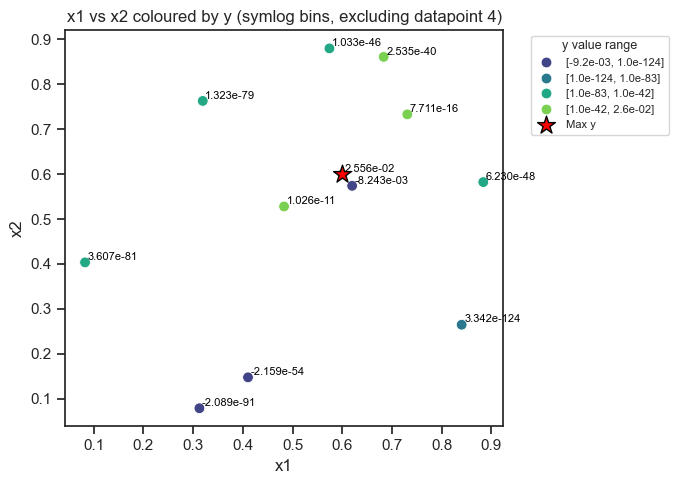

In [2]:
plt.figure(figsize=(7, 5))
df_plot = df.drop(index=4).copy()
y_vals = df_plot["y"]
vmin, vmax = y_vals.min(), y_vals.max()
y_pos = y_vals[y_vals > 0]
if len(y_pos) > 0:
    exp_min, exp_max = int(np.floor(np.log10(y_pos.min()))), int(np.ceil(np.log10(y_pos.max())))
    bins = [vmin]
    if y_pos.min() > 1e-12:
        bins.append(0)
    step = max(1, (exp_max - exp_min) // 3)
    bins.extend([10**e for e in range(exp_min, exp_max + 1, step)])
    bins.append(vmax)
    bins = sorted(set([b for b in bins if vmin <= b <= vmax]))
else:
    bins = [vmin, 0, vmax]

df_plot["y_group"] = pd.cut(df_plot["y"], bins=bins, include_lowest=True, duplicates="drop")
label_map = {cat: f"[{cat.left:.1e}, {cat.right:.1e}]" for cat in df_plot["y_group"].cat.categories}
df_plot["y_label"] = df_plot["y_group"].map(label_map)

scatter = sns.scatterplot(
    data=df_plot,
    x="x1",
    y="x2",
    hue="y_label",
    palette="viridis",
    s=60,
    legend="auto",
)

max_idx = df_plot["y"].idxmax()
max_row = df_plot.loc[max_idx]
plt.scatter(max_row["x1"], max_row["x2"], marker="*", s=180, c="red", edgecolor="black", label="Max y")

for _, row in df_plot.iterrows():
    plt.text(row["x1"] + 0.005, row["x2"] + 0.005, f"{row['y']:.3e}", fontsize=8, color="black")

plt.title("x1 vs x2 coloured by y (symlog bins, excluding datapoint 4)")
plt.legend(title="y value range", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.show()


## Local directional gradient around the current best

We estimate a *local* slope using only the closest neighbours of the max (not all points, and excluding the outlier at index 4):
- Select the k nearest neighbours (capped and distance-weighted) around the max point.
- Fit a weighted plane `y ≈ a*x1 + b*x2 + c` where weights are `1 / distance` so closer points dominate.
- Take the gradient `(a, b)` as the steepest-ascent direction near the max.
- Compare this with two heuristics: move toward the **second-highest** point, and move **directly away from the most negative** point.

This yields three small-step candidates from the current max plus a plot of the suggested directions.


,x1,x2,y,note
max,0.600000,0.600000,0.025559,Current max
grad_step,0.601042,0.649989,NaN,Step along local gradient (weighted plane fit)
toward_second,0.557417,0.573795,NaN,Step toward 2nd-highest point
away_from_negative,0.569514,0.639631,NaN,Step away from most negative point


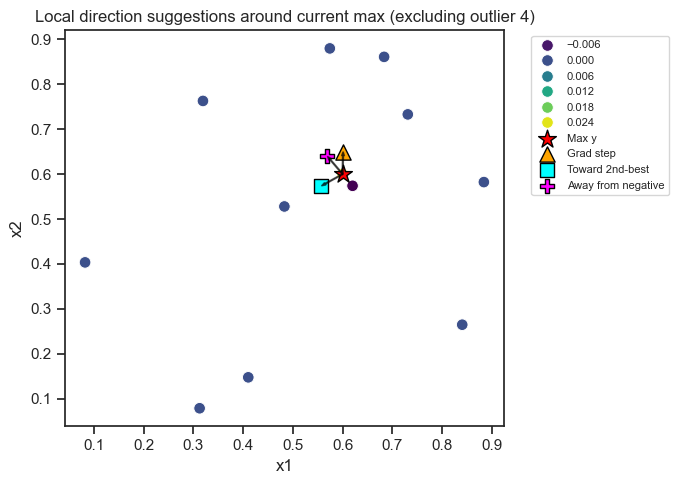

In [3]:
from sklearn.linear_model import LinearRegression

# Exclude the strong outlier at index 4 to avoid distorting the local fit
_df = df.drop(index=4).copy()
best_idx = _df["y"].idxmax()
best = _df.loc[best_idx, ["x1", "x2", "y"]]

# Nearest neighbours around the best point (exclude the best itself); keep it local
_df["dist_to_best"] = np.linalg.norm(_df[["x1", "x2"]].values - best[["x1", "x2"]].values, axis=1)
neighbor_radius = 0.18
neighbors_pool = _df.drop(index=best_idx)
neighbors = neighbors_pool[neighbors_pool["dist_to_best"] <= neighbor_radius]
if len(neighbors) < 3:  # fallback: take the closest few if radius is too tight
    neighbors = neighbors_pool.nsmallest(min(6, len(neighbors_pool)), "dist_to_best")

# Weighted local plane y ~= a*x1 + b*x2 + c
X_lin = neighbors[["x1", "x2"]].values
y_lin = neighbors["y"].values
weights = 1.0 / (neighbors["dist_to_best"].values + 1e-6)
linreg = LinearRegression()
linreg.fit(X_lin, y_lin, sample_weight=weights)

grad = linreg.coef_
grad_norm = np.linalg.norm(grad)
grad_dir = grad / grad_norm if grad_norm > 0 else np.zeros_like(grad)

step = 0.05  # small move to stay local
suggest_grad = np.clip(best[["x1", "x2"]].values + grad_dir * step, 0, 1)

# Move toward second-highest point
_df_sorted = _df.sort_values("y", ascending=False)
second = _df_sorted.iloc[1]
vec_second = second[["x1", "x2"]].values - best[["x1", "x2"]].values
norm_second = np.linalg.norm(vec_second)
dir_second = vec_second / norm_second if norm_second > 0 else np.zeros_like(vec_second)
suggest_second = np.clip(best[["x1", "x2"]].values + dir_second * step, 0, 1)

# Move away from the most negative point
worst = _df.loc[_df["y"].idxmin()]
vec_away = best[["x1", "x2"]].values - worst[["x1", "x2"]].values
norm_away = np.linalg.norm(vec_away)
dir_away = vec_away / norm_away if norm_away > 0 else np.zeros_like(vec_away)
suggest_away = np.clip(best[["x1", "x2"]].values + dir_away * step, 0, 1)

summary = pd.DataFrame(
    {
        "x1": [best.x1, suggest_grad[0], suggest_second[0], suggest_away[0]],
        "x2": [best.x2, suggest_grad[1], suggest_second[1], suggest_away[1]],
        "y": [best.y, np.nan, np.nan, np.nan],
        "note": [
            "Current max",
            "Step along local gradient (weighted plane fit)",
            "Step toward 2nd-highest point",
            "Step away from most negative point",
        ],
    },
    index=["max", "grad_step", "toward_second", "away_from_negative"],
)

display(summary)

# Visualise directions
plt.figure(figsize=(7, 5))
sns.scatterplot(data=_df, x="x1", y="x2", hue="y", palette="viridis", s=70, legend="auto")
plt.scatter(best.x1, best.x2, marker="*", s=180, c="red", edgecolor="black", label="Max y")
plt.scatter(*suggest_grad, marker="^", s=120, c="orange", edgecolor="black", label="Grad step")
plt.scatter(*suggest_second, marker="s", s=90, c="cyan", edgecolor="black", label="Toward 2nd-best")
plt.scatter(*suggest_away, marker="P", s=100, c="magenta", edgecolor="black", label="Away from negative")

for src, dest in [
    (best[["x1", "x2"]].values, suggest_grad),
    (best[["x1", "x2"]].values, suggest_second),
    (best[["x1", "x2"]].values, suggest_away),
]:
    plt.arrow(
        src[0],
        src[1],
        dest[0] - src[0],
        dest[1] - src[1],
        width=0.002,
        length_includes_head=True,
        color="black",
        alpha=0.6,
    )

plt.title("Local direction suggestions around current max (excluding outlier 4)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()



### How to interpret the directions
- **Gradient step**: preferred if the local plane fit returns a clear slope (non-zero coefficients). It approximates steepest ascent nearby and respects all neighbours, including small positives.
- **Toward second-highest**: safe fallback if the gradient is flat/unstable; it keeps us in the quadrant already showing positives.
- **Away from the negative**: hedge against the sharp drop we saw where `x2 < x1`; moving opposite that vector avoids the direction that produced the negative reading.

If the gradient norm prints as ~0, default to the "toward second-highest" or "away from negative" candidates. The table above lists coordinates for all three small steps so you can pick the most conservative next probe.


## Bayesian optimisation (EI), refocused locally near the max

Last week's pick drifted away from the known hotspot; given we already observed a sharp drop (including a negative reading) when moving off the max, we refocus the EI search to a tight window around the current best and keep the `x2 ≥ x1` constraint.

Concretely, we:

1. Fit a GP surrogate on the observed points (excluding the outlier) with a radial feature around `(0.6, 0.6)`.
2. Evaluate EI only in a local window around the current max (small grid), not the whole `[0,1]^2`.
3. Keep the closed-form EI and **hard constraint `x2 ≥ x1`** to avoid the direction that yielded the negative reading.

`candidate_df_feasible` below lists the top EI points in that local neighbourhood; the plot highlights the local maximiser.


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better v

,x1,x2,mu,sigma,ei
1595,0.658861,0.658861,-0.006203,0.007816,1.998757e-14
1762,0.643671,0.670253,-0.006297,0.007830,1.997049e-14
1877,0.628481,0.677848,-0.006265,0.007825,1.996681e-14
1650,0.655063,0.662658,-0.006171,0.007811,1.995016e-14
1934,0.613291,0.681646,-0.006296,0.007829,1.991202e-14


Suggested next query (EI maximiser, x2>=x1): (0.659, 0.659)
Posterior mean: -0.0062, std: 0.0078, EI: 0.000000


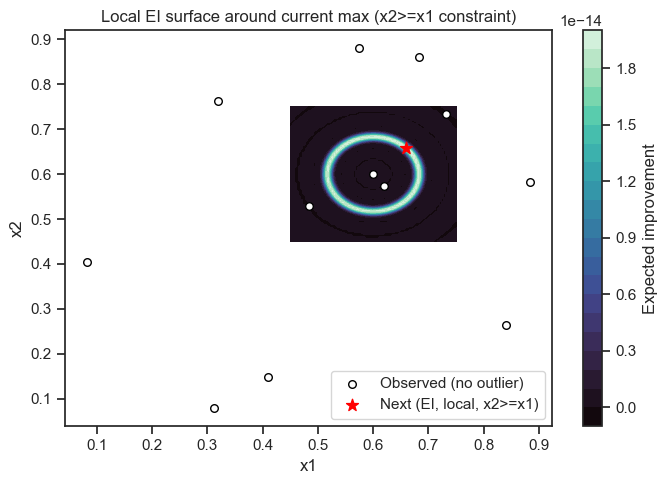

In [4]:
from scipy.special import erf
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

anchor = np.array([0.6, 0.6])

def add_radial_feature(points: np.ndarray) -> np.ndarray:
    dist = np.linalg.norm(points - anchor, axis=1, keepdims=True)
    proximity = np.exp(-5.0 * dist)  # exp(-5*d) so nearby points have high feature value
    return np.hstack([points, proximity])

df_ei = df.drop(index=4).copy()
X_train = df_ei[["x1", "x2"]].values
y_train = df_ei["y"].values
best_ei = df_ei.loc[df_ei["y"].idxmax(), ["x1", "x2"]]

X_aug = add_radial_feature(X_train)

# Train a GP surrogate with bounds that avoid convergence warnings
kernel = ConstantKernel(1.0, (1e-2, 50.0)) * Matern(length_scale=[0.3, 0.3, 0.3], length_scale_bounds=(1e-2, 5.0), nu=1.5) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-1))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=15, random_state=42)
gp.fit(X_aug, y_train)

# Evaluate a dense grid of candidates in a local window around the best point
local_r = 0.15
x1_min, x1_max = max(best_ei.x1 - local_r, 0.0), min(best_ei.x1 + local_r, 1.0)
x2_min, x2_max = max(best_ei.x2 - local_r, 0.0), min(best_ei.x2 + local_r, 1.0)
grid_x1 = np.linspace(x1_min, x1_max, 80)
grid_x2 = np.linspace(x2_min, x2_max, 80)
mesh = np.array(np.meshgrid(grid_x1, grid_x2)).reshape(2, -1).T
mesh_aug = add_radial_feature(mesh)
mu, sigma = gp.predict(mesh_aug, return_std=True)
y_best = y_train.max()
xi = 0.02  # small xi to stay exploitative locally

# Expected improvement acquisition function
def norm_cdf(z):
    return 0.5 * (1.0 + erf(z / np.sqrt(2)))

def norm_pdf(z):
    return np.exp(-0.5 * z**2) / np.sqrt(2 * np.pi)

sigma_safe = np.maximum(sigma, 1e-9)
z = (mu - y_best - xi) / sigma_safe
ei = (mu - y_best - xi) * norm_cdf(z) + sigma_safe * norm_pdf(z)
ei[sigma <= 1e-9] = 0.0

candidate_df = pd.DataFrame(mesh, columns=["x1", "x2"])
candidate_df["mu"] = mu
candidate_df["sigma"] = sigma
candidate_df["ei"] = ei

# HARD CONSTRAINT: enforce x2 >= x1 based on Week 2 evidence
candidate_df_feasible = candidate_df[candidate_df["x2"] >= candidate_df["x1"]].reset_index(drop=True)
next_point = candidate_df_feasible.loc[candidate_df_feasible["ei"].idxmax()]

display(candidate_df_feasible.nlargest(5, "ei"))
print(f"Suggested next query (EI maximiser, x2>=x1): ({next_point.x1:.3f}, {next_point.x2:.3f})")
print(f"Posterior mean: {next_point.mu:.4f}, std: {next_point.sigma:.4f}, EI: {next_point.ei:.6f}")

# Visualise EI surface with current observations and recommended point
ei_grid = candidate_df["ei"].values.reshape(len(grid_x2), len(grid_x1))
plt.figure(figsize=(7, 5))
contour = plt.contourf(grid_x1, grid_x2, ei_grid, levels=20, cmap="mako")
plt.colorbar(contour, label="Expected improvement")
plt.scatter(df_ei["x1"], df_ei["x2"], c="white", s=30, edgecolor="black", label="Observed (no outlier)")
plt.scatter(next_point.x1, next_point.x2, c="red", s=80, marker="*", label="Next (EI, local, x2>=x1)")
plt.title("Local EI surface around current max (x2>=x1 constraint)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Final shortlist of candidate moves
The table below consolidates the local gradient-based suggestions and the top local EI points (constrained to stay near the max and with `x2 ≥ x1`). Pick the point you prefer; I recommend favouring the gradient step if its slope is non-zero, otherwise the safest is toward the second-highest point.


In [5]:
options = []

if "summary" in globals():
    opt = summary.reset_index().rename(columns={"index": "id"})
    opt["source"] = "local_gradient"
    opt = opt[["source", "id", "x1", "x2", "note", "y"]]
    options.append(opt)

if "candidate_df_feasible" in globals():
    top_ei = candidate_df_feasible.nlargest(3, "ei").copy()
    top_ei["id"] = [f"ei_top_{i+1}" for i in range(len(top_ei))]
    top_ei["note"] = "Local EI (x2>=x1)"
    top_ei["source"] = "local_ei"
    top_ei = top_ei[["source", "id", "x1", "x2", "note", "ei", "mu", "sigma"]]
    options.append(top_ei)

if options:
    final_options = pd.concat(options, ignore_index=True)
    display(final_options)
else:
    print("Run the gradient and EI cells first to populate options.")



,source,id,x1,x2,note,y,ei,mu,sigma
0,local_gradient,max,0.600000,0.600000,Current max,0.025559,NaN,NaN,NaN
1,local_gradient,grad_step,0.601042,0.649989,Step along local gradient (weighted plane fit),NaN,NaN,NaN,NaN
2,local_gradient,toward_second,0.557417,0.573795,Step toward 2nd-highest point,NaN,NaN,NaN,NaN
3,local_gradient,away_from_negative,0.569514,0.639631,Step away from most negative point,NaN,NaN,NaN,NaN
4,local_ei,ei_top_1,0.658861,0.658861,Local EI (x2>=x1),NaN,1.998757e-14,-0.006203,0.007816
5,local_ei,ei_top_2,0.643671,0.670253,Local EI (x2>=x1),NaN,1.997049e-14,-0.006297,0.007830
6,local_ei,ei_top_3,0.628481,0.677848,Local EI (x2>=x1),NaN,1.996681e-14,-0.006265,0.007825


## Updated Analysis and Recommendation (EI)

We now keep EI tightly focused around the current max and set a small exploration margin (**ξ = 0.02**) to avoid drifting. The search window is a ±0.15 box around the best point, still constrained to `x2 ≥ x1` to avoid the direction that produced the negative reading.

Because last week's pick strayed from the hotspot, the shortlist now prioritises local moves only. Using the table above we pick the point (0.601042,0.649989) for the next evaluation but given the speed of drop off of the signal we stick with a x2 closer to 0.6 --> final choice (0.601042,0.62)
